In [ ]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.model_selection import train_test_split
df=pd.read_csv("insurance.csv")
print(df.shape)
print(df.head())
print(df.isnull().sum())


(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
df=pd.get_dummies(df,drop_first=True,dtype=int)
print(df.head())
print(df.columns)

   age     bmi  children  ...  region_northwest  region_southeast  region_southwest
0   19  27.900         0  ...                 0                 0                 1
1   18  33.770         1  ...                 0                 1                 0
2   28  33.000         3  ...                 0                 1                 0
3   33  22.705         0  ...                 1                 0                 0
4   32  28.880         0  ...                 1                 0                 0

[5 rows x 9 columns]
Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [ ]:
x=df.drop(columns=['charges'])
y=df['charges']
print(x.shape)
print(y.shape)

(1338, 8)
(1338,)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(1070, 8)
(268, 8)
(1070,)
(268,)


In [ ]:
model=linear_model.LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred[:5])
y_test.values[:5]

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]


array([ 9095.06825,  5272.1758 , 29330.98315,  9301.89355, 33750.2918 ])

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))


4181.19447375365
33596915.85136145
0.7835929767120724


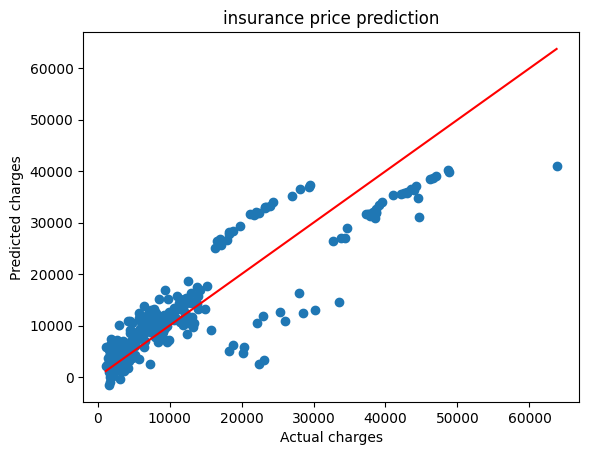

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("insurance price prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()